In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.analysis_utils import (
    drop_missing,
    subset_variables,
    recode_vaccination_variables,
    chi2_cramers_v_weighted,
    normalized_crosstab,
    screen_categorical_associations,
    fit_weighted_logit,
    fit_weighted_ordinal_logit,
    extract_odds_ratios,
    plot_heatmap,
    plot_odds_ratios,
    plot_weighted_coverage_bar,
    plot_stacked_vaccination
)

In [2]:
# Path relative to script.py
csv_path = "../data/cleaned_data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Display first 5 rows
df.head()

,Mothers_id,Birth_Order,Cluster_id,Household_id,Respondents_line_number,v005,Childs_Age,Received_Hep_B_at_birth,Hep_B_1,Hep_B_2,...,hhid,Number_of_household_members,Number_of_children_under_5,Result_of_household_interview,Region,Type_of_place_of_residence,Translator_used,Vaccination_at_Birth,Vaccination_Flag,wt
0,205 12 2,2,205,12,2,552441,14,Vaccination date on card,No,No,...,205 12,4,2,Completed,Kampot,Urban,No,True,None Post Birth,0.552441
1,512 26 7,1,512,26,7,297079,8,Vaccination date on card,No,No,...,512 26,14,3,Completed,Preah Sihanouk,Rural,No,True,None Post Birth,0.297079
2,512 29 5,1,512,29,5,297079,4,No,No,No,...,512 29,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.297079
3,641 16 1,2,641,16,1,64896,21,Vaccination date on card,No,No,...,641 16,3,2,Completed,Kep,Urban,No,True,None Post Birth,0.064896
4,513 6 1,4,513,6,1,287780,32,No,No,No,...,513 6,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.287780


In [3]:
df["Vaccination_at_Birth"] = df["Vaccination_at_Birth"].astype(int)

In [4]:
df["Birth_Order"].value_counts().sort_index()

Birth_Order
1     1613
2     1715
3      942
4      316
5      137
6       51
7       23
8        5
9        7
10       4
13       1
Name: count, dtype: int64

In [5]:
bord_test_df = df[df['Birth_Order'] <= 6].copy()

   Birth_Order  Coverage
0            1  0.925558
1            2  0.946954
2            3  0.944062
3            4  0.896086
4            5  0.906217
5            6  0.810749


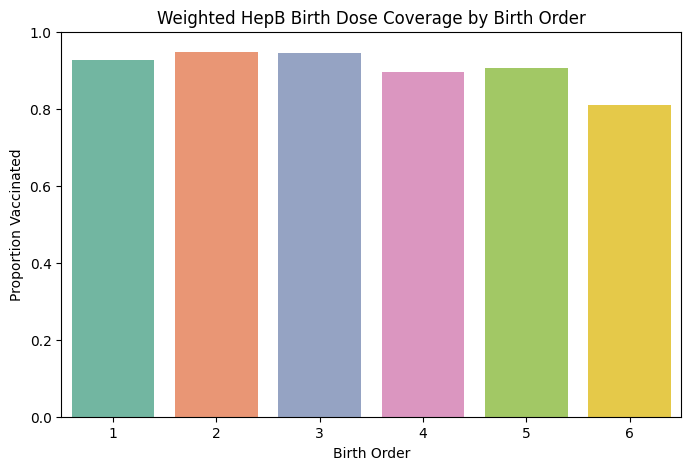

In [6]:
# --- Weighted coverage by Birth Order ---
coverage_birth = (
    bord_test_df.groupby("Birth_Order").apply(
        lambda x: pd.Series({
            "Coverage": (x["Vaccination_at_Birth"] * x["wt"]).sum() / x["wt"].sum()
        }),
        include_groups=False
    ).reset_index()
)
print(coverage_birth)

# --- Plot ---
plt.figure(figsize=(8,5))
sns.barplot(data=coverage_birth, x="Birth_Order", y="Coverage", hue="Birth_Order", palette="Set2", legend=False)
plt.title("Weighted HepB Birth Dose Coverage by Birth Order")
plt.ylabel("Proportion Vaccinated")
plt.xlabel("Birth Order")
plt.ylim(0,1)
plt.savefig("cambodia_birth_dose_coverage_bord.png", bbox_inches='tight', dpi=300)
plt.show()

In [7]:
# --- Prepare data ---
df_clean = drop_missing(bord_test_df, ["Birth_Order", "Vaccination_at_Birth", "wt"])

# --- Fit weighted logistic regression ---
logit_result = fit_weighted_logit(df_clean, "Vaccination_at_Birth ~ Birth_Order", weight_col="wt")
print(logit_result.summary())

# --- Odds ratios and 95% CIs ---
or_df = extract_odds_ratios(logit_result)
or_df.columns = ["OR", "OR_2.5%", "OR_97.5%", "p_value"]
print("\nOdds ratios with 95% CI:")
print(or_df)

                  Generalized Linear Model Regression Results                   
Dep. Variable:     Vaccination_at_Birth   No. Observations:                 4774
Model:                              GLM   Df Residuals:                  4706.97
Model Family:                  Binomial   Df Model:                            1
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -1148.7
Date:                  Wed, 04 Mar 2026   Deviance:                       2297.3
Time:                          10:05:53   Pearson chi2:                 4.72e+03
No. Iterations:                       6   Pseudo R-squ. (CS):          0.0006603
Covariance Type:              nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.8417      0.

In [8]:
# --- Recode and clean ---
bord_test_df = recode_vaccination_variables(bord_test_df)
bord_test_df = bord_test_df[bord_test_df['Birth_Order'] <= 10].copy()
bord_test_df = drop_missing(bord_test_df, ['Vaccination_Flag_ord', 'wt'])

# --- Fit weighted ordinal logistic regression ---
or_df = fit_weighted_ordinal_logit(
    df=bord_test_df,
    outcome="Vaccination_Flag_ord",
    predictors=["Birth_Order"],
    weight_col="wt"
)

# --- Print Summary ---
print(f"--- Ordinal Logistic Regression (N={len(bord_test_df)}) ---")
print("\nCumulative Odds Ratios:")
print(or_df.drop(columns='t_value').to_string())

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


--- Ordinal Logistic Regression (N=4774) ---

Cumulative Odds Ratios:
                   OR  CI_lower  CI_upper
Birth_Order  0.891570  0.812367  0.978494
0|1          0.058062  0.046049  0.073208
1|2          0.093768  0.074105  0.118649
2|3          0.140311  0.111048  0.177285


<Axes: xlabel='Birth Order', ylabel='Proportion'>

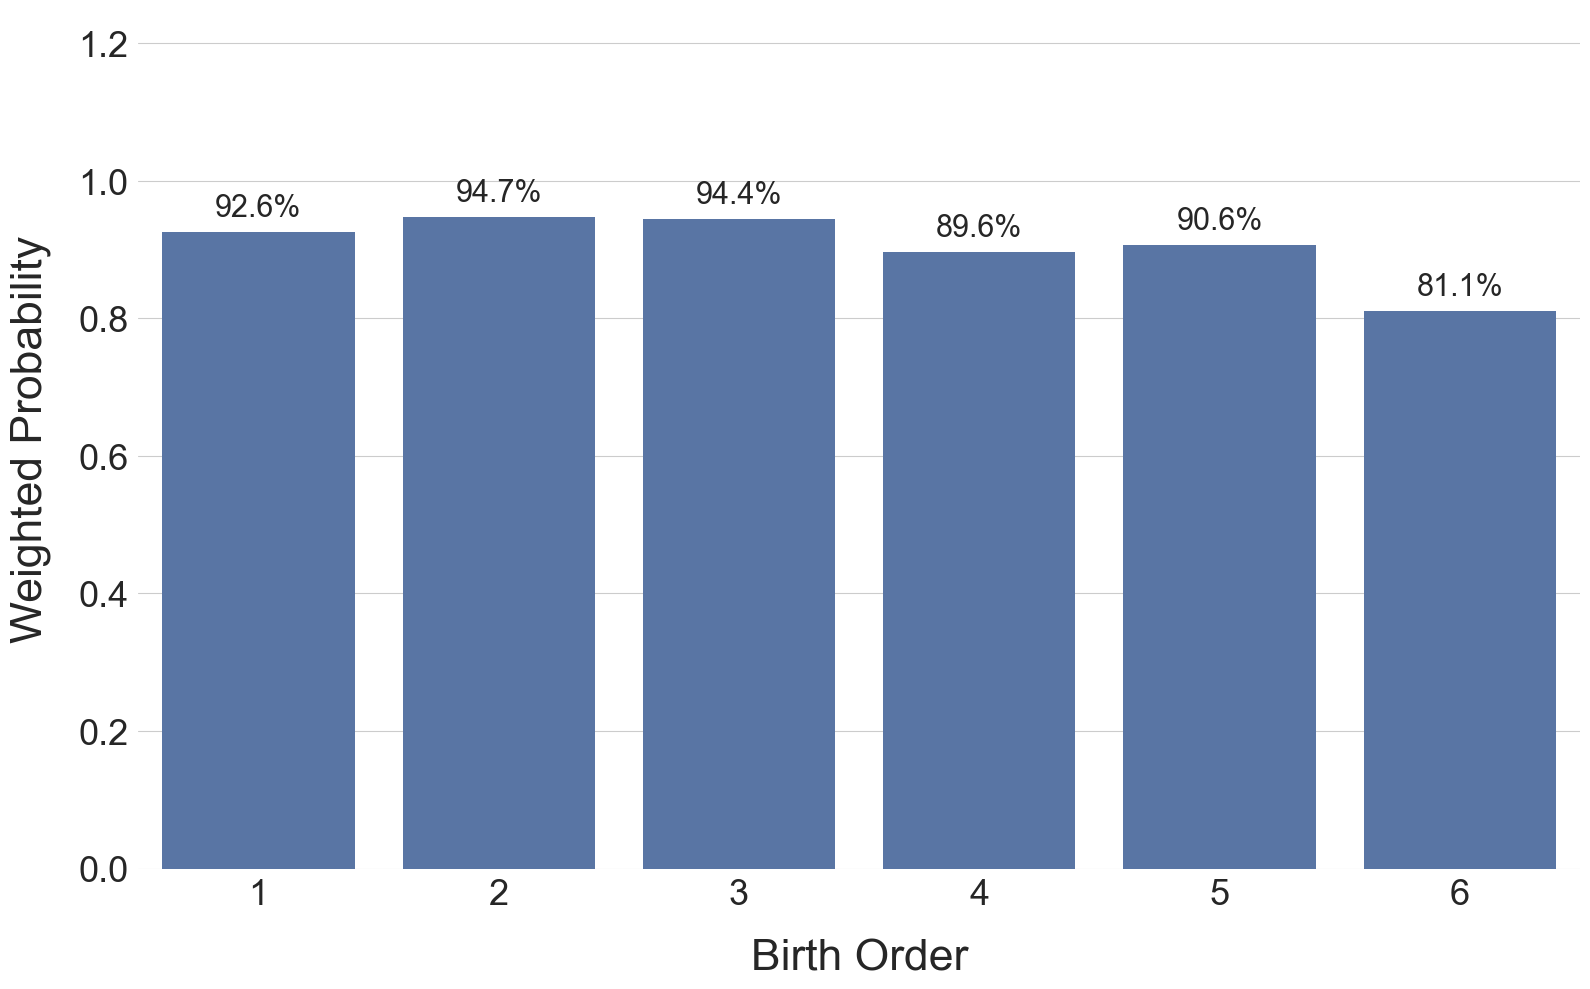

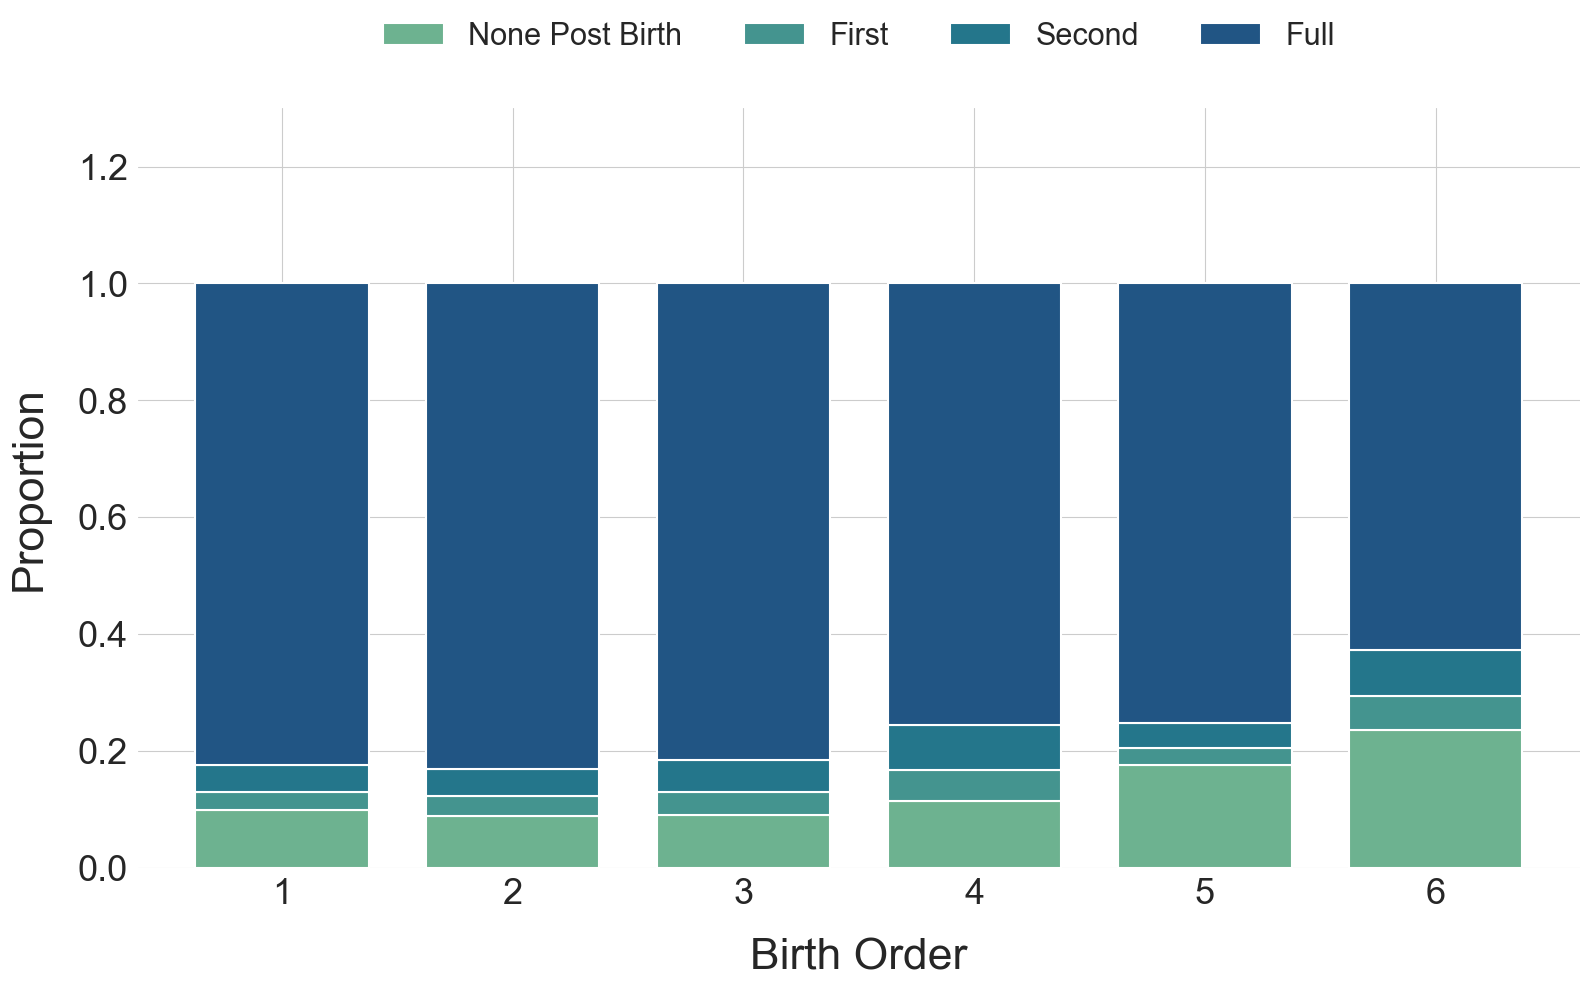

In [9]:
# ------------------------------------------------------------
# 1. Encoding & Data Prep
# ------------------------------------------------------------
bord_test_df = recode_vaccination_variables(bord_test_df)
viz_df = drop_missing(
    bord_test_df[bord_test_df['Birth_Order'] <= 6].copy(),
    ['Vaccination_at_Birth', 'Vaccination_Flag', 'wt']
)

# ------------------------------------------------------------
# 2. Weighted Stats
# ------------------------------------------------------------
coverage_birth = viz_df.groupby("Birth_Order").apply(
    lambda x: np.average(x["Vaccination_at_Birth_bin"], weights=x["wt"]),
    include_groups=False
).reset_index(name="Coverage")

vax_comp = normalized_crosstab(viz_df, 'Birth_Order', 'Vaccination_Flag')[
    ['None Post Birth', 'First', 'Second', 'Full']
]

# ------------------------------------------------------------
# 3. Plotting
# ------------------------------------------------------------
plot_weighted_coverage_bar(
    coverage_birth,
    x="Birth_Order",
    y="Coverage",
    xlabel="Birth Order",
    save_path="birth_order_initiation.png"
)

plot_stacked_vaccination(
    vax_comp,
    xlabel="Birth Order",
    save_path="birth_order_persistence.png"
)

In [10]:
# --- 1. Create sibling history df ---
sib_df = drop_missing(
    df[["Mothers_id", "Birth_Order", "Vaccination_at_Birth", "wt"]].copy(),
    ["Mothers_id", "Birth_Order", "Vaccination_at_Birth", "wt"]
)
sib_df["Birth_Order"] = sib_df["Birth_Order"].astype(int)

# --- 2. History Logic ---
sib_df = sib_df.sort_values(["Mothers_id", "Birth_Order"])
sib_df["Prev_Stat"] = sib_df.groupby("Mothers_id")["Vaccination_at_Birth"].shift(1)
sib_df["History_Cat"] = pd.Categorical(
    sib_df["Prev_Stat"].map(
        lambda x: "0_No_Prev_Data" if pd.isnull(x)
        else ("2_Prev_Child_Yes" if x == 1 else "1_Prev_Child_No")
    ),
    categories=["0_No_Prev_Data", "1_Prev_Child_No", "2_Prev_Child_Yes"]
)

In [11]:
# --- 3. Fit Binary Logit ---
logit_res = fit_weighted_logit(
    sib_df,
    "Vaccination_at_Birth ~ C(History_Cat)",
    weight_col="wt"
)
print(f"\n--- Binary Logistic Regression (N={len(sib_df)}) ---")
print(logit_res.summary())

# --- 4. Odds Ratios ---
or_df = extract_odds_ratios(logit_res)
or_df = or_df[or_df.index != 'Intercept'].drop(columns='p_value')
or_df.columns = ["OR", "OR_2.5%", "OR_97.5%"]
print("\nOdds Ratios (Relative to No Previous Data):")
print(or_df)


--- Binary Logistic Regression (N=4814) ---
                  Generalized Linear Model Regression Results                   
Dep. Variable:     Vaccination_at_Birth   No. Observations:                 4814
Model:                              GLM   Df Residuals:                  4736.66
Model Family:                  Binomial   Df Model:                            2
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -1158.1
Date:                  Wed, 04 Mar 2026   Deviance:                       2316.1
Time:                          10:06:04   Pearson chi2:                 4.74e+03
No. Iterations:                       6   Pseudo R-squ. (CS):           0.003880
Covariance Type:              nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

In [12]:
# --- 1. Create ordinal sibling history df ---
sib_ord_df = drop_missing(
    df[["Mothers_id", "Birth_Order", "Vaccination_Flag", "Vaccination_at_Birth", "wt"]].copy(),
    ["Mothers_id", "Birth_Order", "Vaccination_Flag", "Vaccination_at_Birth", "wt"]
)
sib_ord_df = recode_vaccination_variables(sib_ord_df)
sib_ord_df["Birth_Order"] = sib_ord_df["Birth_Order"].astype(int)

# --- 2. History Logic ---
sib_ord_df = sib_ord_df.sort_values(["Mothers_id", "Birth_Order"])
sib_ord_df["Prev_Stat"] = sib_ord_df.groupby("Mothers_id")["Vaccination_at_Birth"].shift(1)
sib_ord_df["History_Cat"] = pd.Categorical(
    sib_ord_df["Prev_Stat"].map(
        lambda x: "0_No_Prev_Data" if pd.isnull(x)
        else ("2_Prev_Child_Yes" if x == 1 else "1_Prev_Child_No")
    ),
    categories=["0_No_Prev_Data", "1_Prev_Child_No", "2_Prev_Child_Yes"]
)

# --- 3. Fit Weighted Ordinal Logit ---
or_df = fit_weighted_ordinal_logit(
    df=sib_ord_df,
    outcome="Vaccination_Flag_ord",
    predictors=["C(History_Cat)"],
    weight_col="wt"
)

# --- 4. Print Results ---
print(f"\n--- Ordinal Logistic Regression (N={len(sib_ord_df)}) ---")
print("\nCumulative Odds Ratios (Relative to No Previous Data):")
print(or_df.drop(columns='t_value').to_string())


--- Ordinal Logistic Regression (N=4814) ---

Cumulative Odds Ratios (Relative to No Previous Data):
                                      OR  CI_lower  CI_upper
C(History_Cat)1_Prev_Child_No   0.130849  0.038025  0.450263
C(History_Cat)2_Prev_Child_Yes  0.839881  0.557630  1.264998
0|1                             0.073242  0.064739  0.082863
1|2                             0.119451  0.106266  0.134271
2|3                             0.178594  0.161104  0.197982


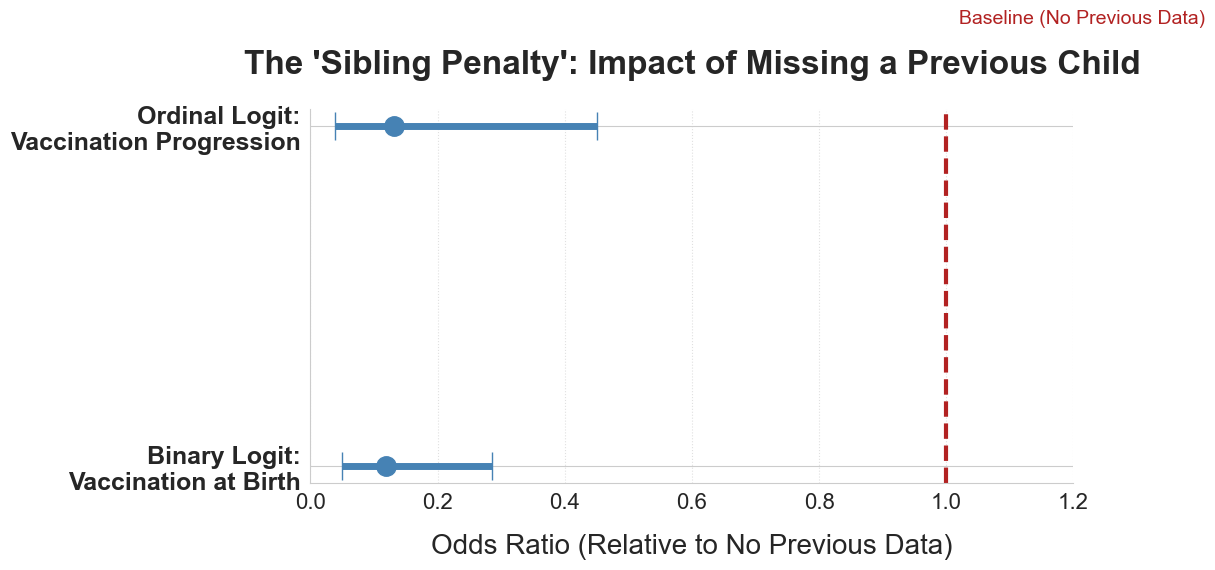

In [15]:
# ---------------------------------------------------------
# 1. Extract the "Sibling Penalty" ORs and CIs
# ---------------------------------------------------------
bin_or_df = extract_odds_ratios(logit_res)
ord_or_df = or_df  # already a dataframe from fit_weighted_ordinal_logit

bin_row = "C(History_Cat)[T.1_Prev_Child_No]"
ord_row = "C(History_Cat)1_Prev_Child_No"

plot_df = pd.DataFrame({
    "Model": [
        "Binary Logit:\nVaccination at Birth",
        "Ordinal Logit:\nVaccination Progression"
    ],
    "OR": [bin_or_df.loc[bin_row, "OR"], ord_or_df.loc[ord_row, "OR"]],
    "CI_low": [bin_or_df.loc[bin_row, "CI_lower"], ord_or_df.loc[ord_row, "CI_lower"]],
    "CI_high": [bin_or_df.loc[bin_row, "CI_upper"], ord_or_df.loc[ord_row, "CI_upper"]]
})

# ---------------------------------------------------------
# 2. Forest Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(plot_df))
ax.errorbar(
    plot_df["OR"],
    y_pos,
    xerr=[
        plot_df["OR"] - plot_df["CI_low"],
        plot_df["CI_high"] - plot_df["OR"]
    ],
    fmt='o',
    capsize=10,
    ms=14,
    elinewidth=5,
    color='steelblue',
    label='Sibling Penalty (vs No Previous Data)'
)
ax.axvline(1, color='firebrick', linestyle='--', linewidth=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["Model"], fontsize=18, fontweight='bold')
ax.set_xlabel("Odds Ratio (Relative to No Previous Data)", fontsize=20, labelpad=15)
ax.set_title("The 'Sibling Penalty': Impact of Missing a Previous Child",
             fontsize=24, pad=25, fontweight='bold')
ax.set_xlim(0, max(plot_df["CI_high"].max() * 1.15, 1.2))
ax.tick_params(axis='x', labelsize=16)
ax.text(1.02, 1.3, "Baseline (No Previous Data)", color='firebrick', fontsize=14)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
# --- 1. Define model columns and clean ---
model_cols = [
    "Mothers_id", "Birth_Order", "Vaccination_Flag", "Vaccination_at_Birth",
    "Mothers_age", "Wealth_index_combined", "Type_of_place_of_residence",
    "Number_of_antenatal_visits_during_pregnancy", "wt"
]
mv_ord_df = drop_missing(df[model_cols].copy(), model_cols)
mv_ord_df = recode_vaccination_variables(mv_ord_df)
mv_ord_df["Birth_Order"] = mv_ord_df["Birth_Order"].astype(int)

# --- 2. History Logic ---
mv_ord_df = mv_ord_df.sort_values(["Mothers_id", "Birth_Order"])
mv_ord_df["Prev_Stat"] = mv_ord_df.groupby("Mothers_id")["Vaccination_at_Birth"].shift(1)
mv_ord_df["History_Cat"] = pd.Categorical(
    mv_ord_df["Prev_Stat"].map(
        lambda x: "0_No_Prev_Data" if pd.isnull(x)
        else ("2_Prev_Child_Yes" if x == 1 else "1_Prev_Child_No")
    ),
    categories=["0_No_Prev_Data", "1_Prev_Child_No", "2_Prev_Child_Yes"]
)

# --- 3. Categorical Controls & Re-leveling ---
mv_ord_df["Age_Cat"] = pd.Categorical(
    pd.cut(mv_ord_df["Mothers_age"], bins=[0, 24, 34, 50], labels=["15-24", "25-34", "35-49"]),
    categories=["25-34", "15-24", "35-49"]
)
mv_ord_df["Wealth_Ref"] = pd.Categorical(
    mv_ord_df["Wealth_index_combined"],
    categories=["Middle", "Poorest", "Poorer", "Richer", "Richest"]
)
mv_ord_df["Residence"] = pd.Categorical(
    mv_ord_df["Type_of_place_of_residence"], categories=["Urban", "Rural"]
)

# --- 4. Fit Weighted Ordinal Logit ---
or_df = fit_weighted_ordinal_logit(
    df=mv_ord_df,
    outcome="Vaccination_Flag_ord",
    predictors=["C(History_Cat)", "Birth_Order", "C(Age_Cat)",
                "C(Wealth_Ref)", "C(Residence)",
                "Number_of_antenatal_visits_during_pregnancy"],
    weight_col="wt"
)

# --- 5. Print Results ---
print(f"\nFINAL MULTIVARIATE ORDERED LOGIT (N={len(mv_ord_df)})")
print("\nAdjusted Odds Ratios (Relative to Reference Categories):")
print(or_df.drop(columns='t_value').to_string())


FINAL MULTIVARIATE ORDERED LOGIT (N=4814)

Adjusted Odds Ratios (Relative to Reference Categories):
                                                   OR  CI_lower  CI_upper
C(History_Cat)1_Prev_Child_No                0.239439  0.079335  0.722651
C(History_Cat)2_Prev_Child_Yes               1.104547  0.715479  1.705185
Birth_Order                                  0.800833  0.725152  0.884413
C(Age_Cat).L                                 1.146140  0.927152  1.416852
C(Age_Cat).Q                                 1.757404  1.381522  2.235554
C(Wealth_Ref)Poorest                         0.650460  0.494696  0.855268
C(Wealth_Ref)Poorer                          1.069033  0.786178  1.453655
C(Wealth_Ref)Richer                          1.152519  0.812620  1.634589
C(Wealth_Ref)Richest                         0.906851  0.618062  1.330576
C(Residence)Rural                            1.159947  0.911689  1.475805
Number_of_antenatal_visits_during_pregnancy  1.199278  1.155454  1.244763
0|1        

In [18]:
# --- 1. Ensure dependent variable is numeric ---
mv_ord_df["Vaccination_at_Birth"] = pd.to_numeric(
    mv_ord_df["Vaccination_at_Birth"], errors='coerce'
).astype(int)

# --- 2. Define formula for binary logit ---
formula = (
    "Vaccination_at_Birth ~ C(History_Cat) + Birth_Order + C(Age_Cat) "
    "+ C(Wealth_Ref) + C(Residence) + Number_of_antenatal_visits_during_pregnancy"
)

# --- 3. Fit weighted binary logistic regression ---
logit_mv = fit_weighted_logit(
    df=mv_ord_df,
    formula=formula,
    weight_col="wt"  # only argument supported for weighting
)

print(f"\nMULTIVARIATE LOGIT: VACCINATION AT BIRTH (N={len(mv_ord_df)})")
print(logit_mv.summary())

# --- 4. Extract adjusted odds ratios ---
or_df = extract_odds_ratios(logit_mv)
or_df = or_df[["OR", "CI_lower", "CI_upper"]]  # optional: drop p_value

print("\nAdjusted Odds Ratios (Relative to Reference Categories):")
print(or_df)


MULTIVARIATE LOGIT: VACCINATION AT BIRTH (N=4814)
                  Generalized Linear Model Regression Results                   
Dep. Variable:     Vaccination_at_Birth   No. Observations:                 4814
Model:                              GLM   Df Residuals:                  4727.66
Model Family:                  Binomial   Df Model:                           11
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -1114.0
Date:                  Wed, 04 Mar 2026   Deviance:                       2228.1
Time:                          10:11:20   Pearson chi2:                 4.78e+03
No. Iterations:                       6   Pseudo R-squ. (CS):            0.02194
Covariance Type:              nonrobust                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

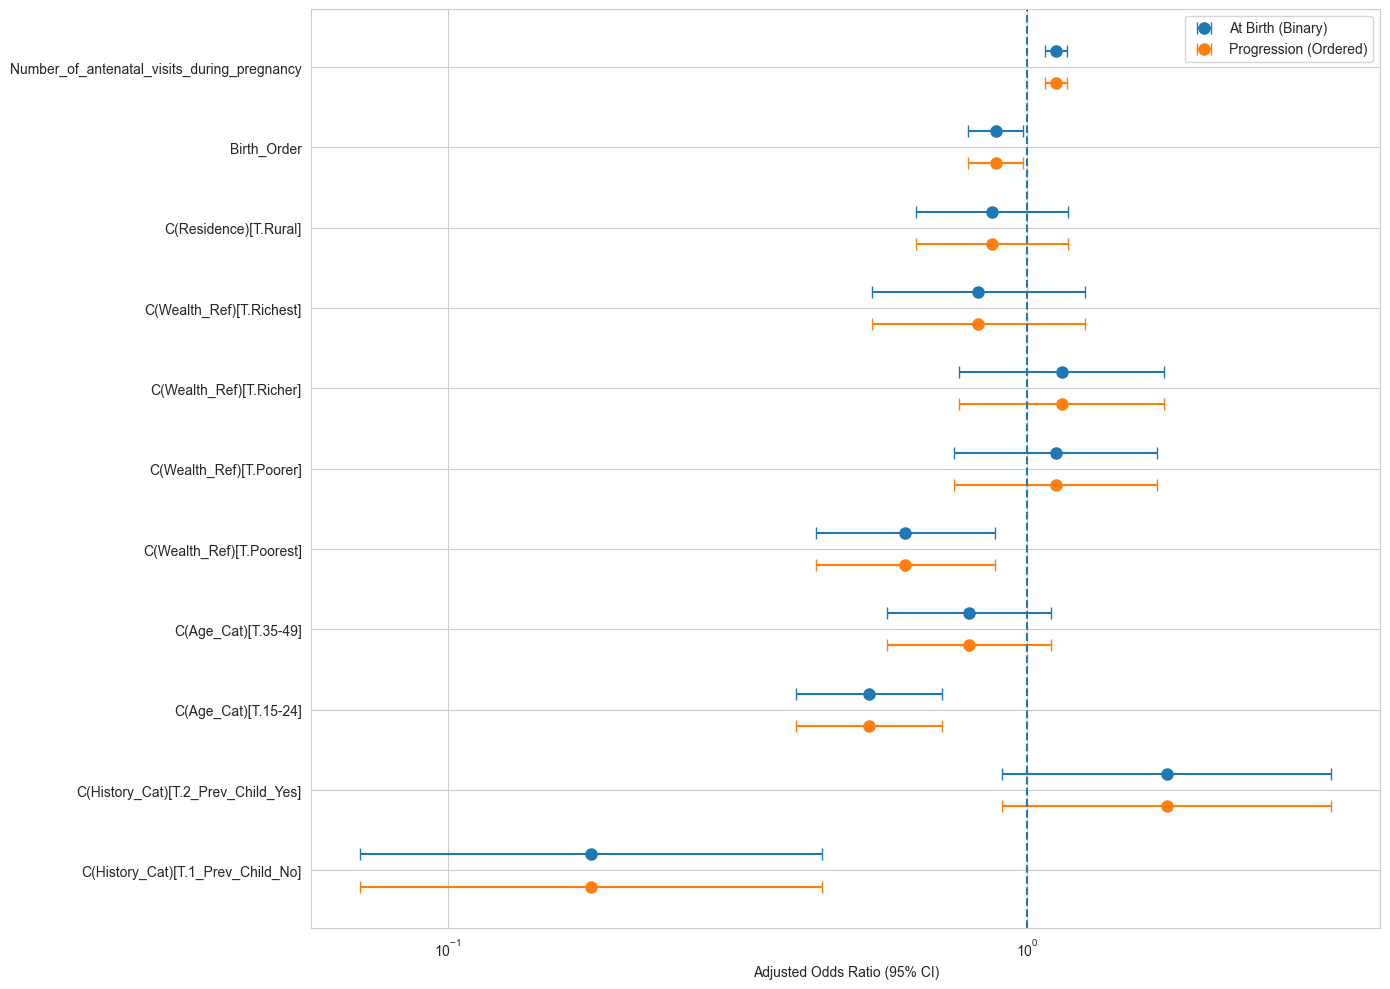

In [19]:
# ---------------------------------------------------------
# 1. Extract Odds Ratios from both models
# ---------------------------------------------------------
bin_or_df = extract_odds_ratios(logit_mv)        # Binary logit model
ord_or_df = or_df                                # Already a dataframe from fit_weighted_ordinal_logit

# Drop intercept (not meaningful in forest plots)
bin_or_df = bin_or_df.drop(index="Intercept", errors="ignore")
ord_or_df = ord_or_df.drop(index="Intercept", errors="ignore")

# ---------------------------------------------------------
# 2. Align variables across both models
# ---------------------------------------------------------
all_vars = bin_or_df.index.union(ord_or_df.index)
or_df_combined = pd.DataFrame({
    "Variable": all_vars,
    "OR_Birth": bin_or_df.reindex(all_vars)["OR"],
    "LCI_Birth": bin_or_df.reindex(all_vars)["CI_lower"],
    "UCI_Birth": bin_or_df.reindex(all_vars)["CI_upper"],
    "OR_Prog": ord_or_df.reindex(all_vars)["OR"],
    "LCI_Prog": ord_or_df.reindex(all_vars)["CI_lower"],
    "UCI_Prog": ord_or_df.reindex(all_vars)["CI_upper"],
}).reset_index(drop=True)

or_df_combined = or_df_combined.dropna(subset=["OR_Birth", "OR_Prog"], how="all")

# ---------------------------------------------------------
# 3. Forest Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))
y_pos = np.arange(len(or_df_combined))

ax.errorbar(
    or_df_combined["OR_Birth"],
    y_pos + 0.2,
    xerr=[
        or_df_combined["OR_Birth"] - or_df_combined["LCI_Birth"],
        or_df_combined["UCI_Birth"] - or_df_combined["OR_Birth"],
    ],
    fmt="o", markersize=8, capsize=4,
    label="At Birth (Binary)",
)
ax.errorbar(
    or_df_combined["OR_Prog"],
    y_pos - 0.2,
    xerr=[
        or_df_combined["OR_Prog"] - or_df_combined["LCI_Prog"],
        or_df_combined["UCI_Prog"] - or_df_combined["OR_Prog"],
    ],
    fmt="o", markersize=8, capsize=4,
    label="Progression (Ordered)",
)

ax.axvline(1, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(or_df_combined["Variable"])
ax.set_xscale("log")
ax.set_xlabel("Adjusted Odds Ratio (95% CI)")
ax.legend()
plt.tight_layout()
plt.show()